In [3]:
!mamba install pandas
!mamba install numpy
!mamba install statsmodels

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.154 seconds
All requested packages already installed.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.852 seconds
All requested packages already installed.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, statsmodels
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.814 seconds
  Name         Version  Build                Channel
------------------------------------------------------------------
+ patsy        1.0.3    py313h1804a44_0      emscripten-forge-4x
+ statsmodels  0.14.6   np23py313hd8db738_2  emscripten-forge-4x


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

In [5]:
# ============================================================
# SETTINGS
# ============================================================

feedback_file = "deep_failure_analysis.csv"
iteration_file = "deep_failure_analysis_iterations.csv"


In [6]:
# ============================================================
# MODEL GROUPS
# ============================================================

llms = [
    "gpt-global",
    "gpt-oss_120b",
    "deepseek-r1_70b"
]

slms = [
    "deepseek-r1_32b",
    "gemma4_31b",
    "gpt-oss_20b",
    "granite4.2_30b",
    "llama3.2_latest",
    "mistral-small3.2_latest",
    "qwen3.8_27b-bf16"
]

In [7]:
# ============================================================
# 1. LOAD FEEDBACK DATA
# ============================================================

df = pd.read_csv(
    feedback_file,
    sep=";"
)

df.columns = df.columns.str.strip()

df["Model"] = df["Model"].astype(str).str.strip()
df["Mode"] = df["Mode"].astype(str).str.strip()
df["Failed Check"] = df["Failed Check"].astype(str).str.strip()

# Convert Count
df["Count"] = (
    df["Count"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df["Count"] = pd.to_numeric(
    df["Count"],
    errors="coerce"
)

# Model group
df["Model Group"] = df["Model"].apply(
    lambda x:
        "LLM" if x in llms
        else "SLM" if x in slms
        else "Unknown"
)

df = df[df["Model Group"] != "Unknown"].copy()

In [8]:
# ============================================================
# 2. MODEL-LEVEL NORMALISATION
# ============================================================

# First aggregate repeated rows for the same
# Model × Mode × Failed Check

model_counts = (
    df.groupby(
        [
            "Model",
            "Model Group",
            "Mode",
            "Failed Check"
        ],
        as_index=False
    )
    .agg(
        Count=("Count", "sum")
    )
)

# Normalize within each individual model and mode
model_counts["Percentage"] = (
    model_counts["Count"]
    /
    model_counts.groupby(
        ["Model", "Mode"]
    )["Count"].transform("sum")
    * 100
)

In [10]:
# ============================================================
# 3. DESCRIPTIVE GROUP RESULTS
# ============================================================

grouped = (
    model_counts
    .groupby(
        [
            "Model Group",
            "Mode",
            "Failed Check"
        ],
        as_index=False
    )
    .agg(
        Mean_Percentage=("Percentage", "mean"),
        SD_Percentage=("Percentage", "std"),
        Number_of_Models=("Model", "nunique")
    )
)

print("\n========================================")
print("MODEL-GROUP DESCRIPTIVE RESULTS")
print("========================================\n")

print(
    grouped.to_string(index=False)
)



MODEL-GROUP DESCRIPTIVE RESULTS

Model Group        Mode  Failed Check  Mean_Percentage  SD_Percentage  Number_of_Models
        LLM    Holistic            C1        10.083845       0.976904                 3
        LLM    Holistic           C10         5.509761       1.487594                 3
        LLM    Holistic           C11         1.663798       0.176355                 3
        LLM    Holistic           C12        10.673959       0.852875                 3
        LLM    Holistic           C13         5.410723            NaN                 1
        LLM    Holistic           C14         0.537503       0.545609                 3
        LLM    Holistic           C15         4.173754       0.098653                 3
        LLM    Holistic           C17        10.754724       0.715067                 3
        LLM    Holistic            C2         8.777476       1.857728                 3
        LLM    Holistic            C4         3.457536       2.414409                 

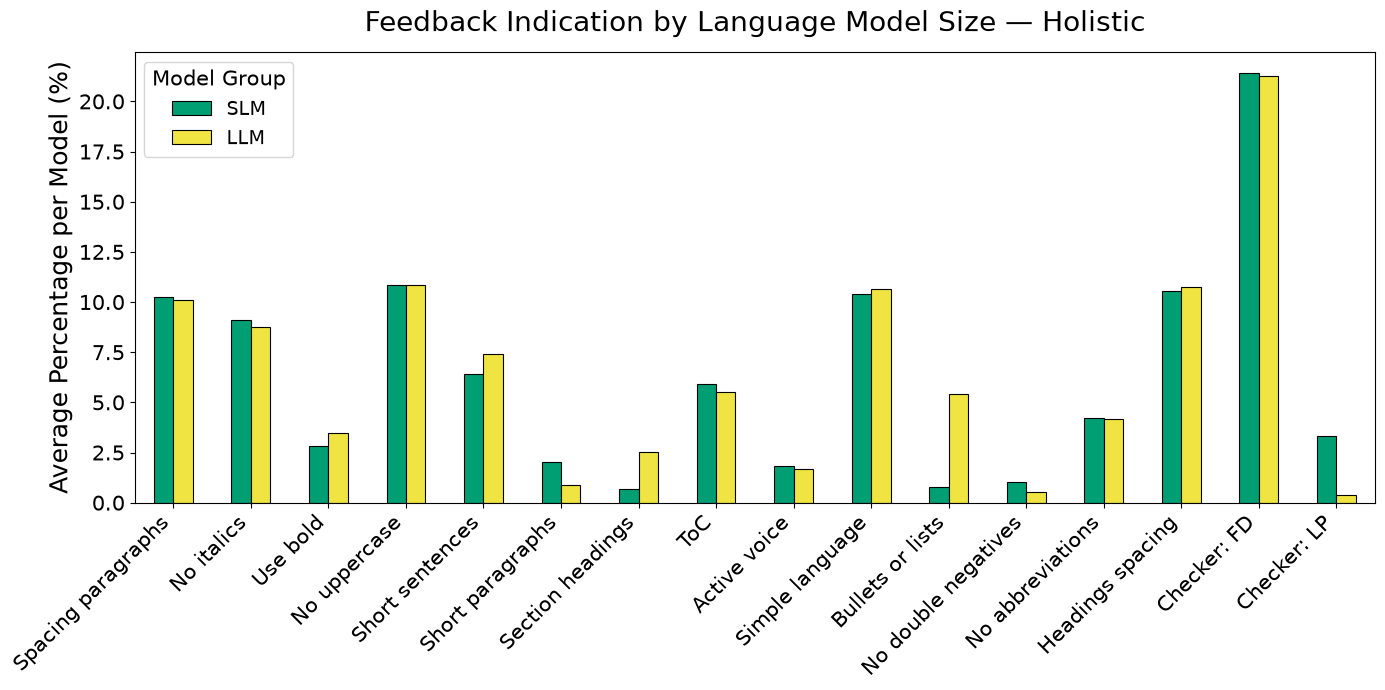

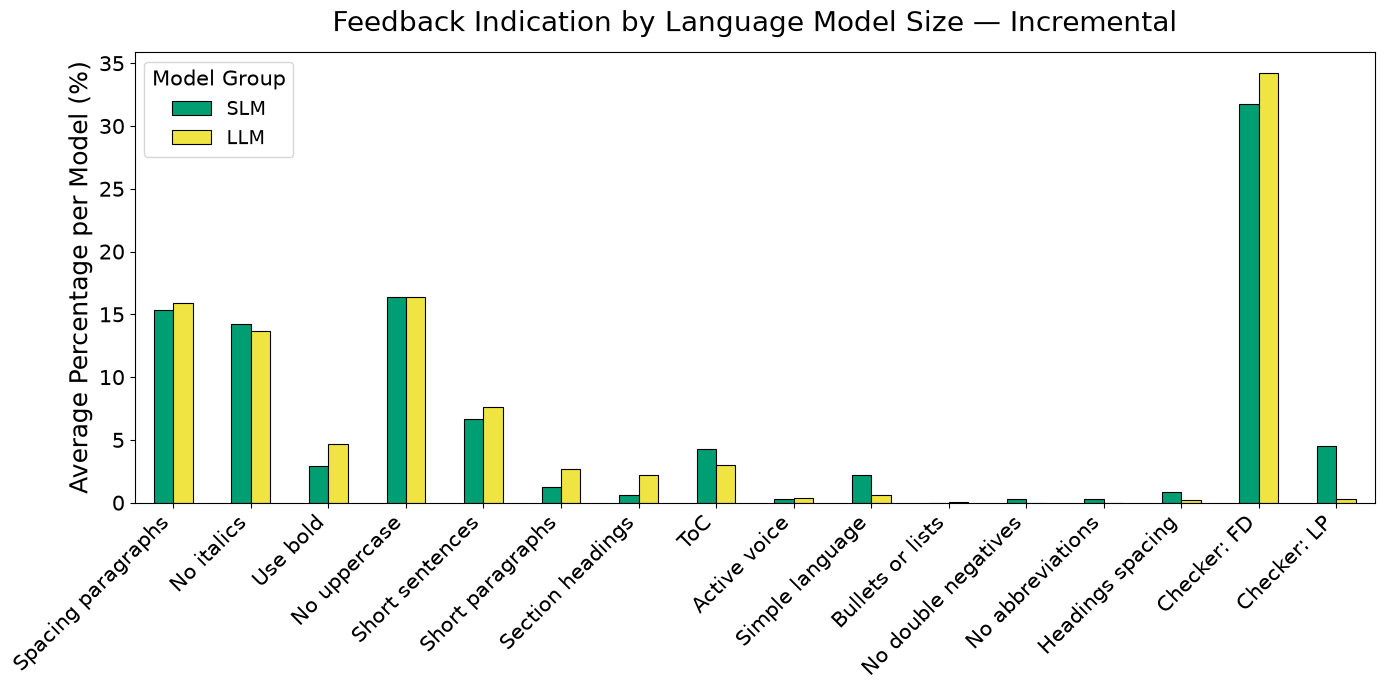

In [11]:
# ============================================================
# 4. DESCRIPTIVE VISUALISATION
# ============================================================

failed_check_labels = {
    "C1": "Spacing paragraphs",
    "C2": "No italics",
    "C3": "No underline",
    "C4": "Use bold",
    "C5": "No uppercase",
    "C6": "Left align",
    "C7": "Short sentences",
    "C8": "Short paragraphs",
    "C9": "Section headings",
    "C10": "ToC",
    "C11": "Active voice",
    "C12": "Simple language",
    "C13": "Bullets or lists",
    "C14": "No double negatives",
    "C15": "No abbreviations",
    "C16": "Avoid columns",
    "C17": "Headings spacing",
    "lix": "LIX",
    "factual_drift": "Checker: FD",
    "longphrase": "Checker: LP"
}

check_order = (
    [f"C{i}" for i in range(1, 18)]
    + ["lix", "factual_drift", "longphrase"]
)


for mode in grouped["Mode"].unique():

    mode_data = grouped[
        grouped["Mode"] == mode
    ]

    plot_data = mode_data.pivot(
        index="Failed Check",
        columns="Model Group",
        values="Mean_Percentage"
    ).fillna(0)

    plot_data = plot_data.reindex(
        [
            c for c in check_order
            if c in plot_data.index
        ]
    )

    plot_data.index = [
        failed_check_labels.get(
            check,
            check
        )
        for check in plot_data.index
    ]

    for group in ["SLM", "LLM"]:
        if group not in plot_data.columns:
            plot_data[group] = 0

    plot_data = plot_data[
        ["SLM", "LLM"]
    ]

    ax = plot_data.plot(
        kind="bar",
        figsize=(14, 7),
        color=[
            "#009E73",
            "#F0E442"
        ],
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(
        f"Feedback Indication by Language Model Size — {mode}",
        fontsize=20,
        pad=15
    )

    ax.set_ylabel(
        "Average Percentage per Model (%)",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    ax.legend(
        title="Model Group",
        fontsize=14,
        title_fontsize=15
    )

    plt.tight_layout()

    safe_mode = (
        str(mode)
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        f"feedback_distribution_{safe_mode}.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()



In [21]:
# ============================================================
# 5. GROUP COMPARISON
#    SLM vs LLM
# ============================================================

print("\n========================================")
print("SLM vs LLM — MANN-WHITNEY U")
print("========================================\n")

group_results = []


for mode in model_counts["Mode"].unique():

    mode_data = model_counts[
        model_counts["Mode"] == mode
    ]

    for check in mode_data["Failed Check"].unique():

        check_data = mode_data[
            mode_data["Failed Check"] == check
        ]

        slm = check_data[
            check_data["Model Group"] == "SLM"
        ]["Percentage"].dropna()

        llm = check_data[
            check_data["Model Group"] == "LLM"
        ]["Percentage"].dropna()

        # Require observations in both groups
        if len(slm) < 2 or len(llm) < 2:
            continue

        result = mannwhitneyu(
            slm,
            llm,
            alternative="two-sided"
        )

        # Rank-biserial correlation
        U = result.statistic
        n1 = len(slm)
        n2 = len(llm)

        r_rb = (
            (2 * U) / (n1 * n2)
            - 1
        )

        

        group_results.append({
            "Mode": mode,
            "Failed Check": check,
            "SLM n": n1,
            "LLM n": n2,
            "SLM Mean (%)": slm.mean(),
            "LLM Mean (%)": llm.mean(),
            "U": U,
            "p": result.pvalue,
            "Rank-biserial r": r_rb
        })


group_results = pd.DataFrame(group_results)

# ------------------------------------------------------------
# Multiple-comparison correction: Holm
# ------------------------------------------------------------

group_results["p_adjusted"] = np.nan

for mode in group_results["Mode"].unique():

    mask = group_results["Mode"] == mode

    group_results.loc[mask, "p_adjusted"] = multipletests(
        group_results.loc[mask, "p"],
        method="holm"
    )[1]

# ------------------------------------------------------------
# Statistical significance after Holm correction
# ------------------------------------------------------------

group_results["Significant"] = np.where(
    group_results["p_adjusted"] < 0.05,
    "Yes",
    "No"
)

print(group_results)

print(group_results)


SLM vs LLM — MANN-WHITNEY U

           Mode   Failed Check  SLM n  LLM n  SLM Mean (%)  LLM Mean (%)  \
0      Holistic             C1      7      3     10.263513     10.083845   
1      Holistic            C10      7      3      5.911055      5.509761   
2      Holistic            C11      7      3      1.822765      1.663798   
3      Holistic            C12      7      3     10.411021     10.673959   
4      Holistic            C14      7      3      1.032338      0.537503   
5      Holistic            C15      7      3      4.233886      4.173754   
6      Holistic            C17      7      3     10.562471     10.754724   
7      Holistic             C2      7      3      9.111792      8.777476   
8      Holistic             C4      5      2      2.839802      3.457536   
9      Holistic             C5      7      3     10.868888     10.866299   
10     Holistic             C7      7      3      6.426284      7.432262   
11     Holistic             C8      7      3      2.039724

In [13]:
# ============================================================
# 6. MULTIPLE-COMPARISON CORRECTION
# ============================================================

if not group_results.empty:

    group_results["p_adjusted"] = np.nan

    for mode in group_results["Mode"].unique():

        mask = (
            group_results["Mode"] == mode
        )

        pvals = group_results.loc[
            mask,
            "p"
        ]

        adjusted = multipletests(
            pvals,
            method="holm"
        )[1]

        group_results.loc[
            mask,
            "p_adjusted"
        ] = adjusted


print(
    group_results.to_string(index=False)
)

group_results.to_csv(
    "slm_vs_llm_mann_whitney.csv",
    index=False
)

       Mode  Failed Check  SLM n  LLM n  SLM Mean (%)  LLM Mean (%)    U        p  Rank-biserial r  p_adjusted
   Holistic            C1      7      3     10.263513     10.083845  9.0 0.833333        -0.142857         1.0
   Holistic           C10      7      3      5.911055      5.509761 12.0 0.833333         0.142857         1.0
   Holistic           C11      7      3      1.822765      1.663798 11.0 1.000000         0.047619         1.0
   Holistic           C12      7      3     10.411021     10.673959  9.0 0.833333        -0.142857         1.0
   Holistic           C14      7      3      1.032338      0.537503 15.0 0.383333         0.428571         1.0
   Holistic           C15      7      3      4.233886      4.173754  9.0 0.833333        -0.142857         1.0
   Holistic           C17      7      3     10.562471     10.754724 11.0 1.000000         0.047619         1.0
   Holistic            C2      7      3      9.111792      8.777476 11.0 1.000000         0.047619         1.0
 

In [24]:
# ============================================================
# 7. FEEDBACK MODE COMPARISON
#    HOLISTIC vs INCREMENTAL
# ============================================================

print("\n========================================")
print("HOLISTIC vs INCREMENTAL — WILCOXON")
print("========================================\n")

mode_results = []


for check in model_counts["Failed Check"].unique():

    check_data = model_counts[
        model_counts["Failed Check"] == check
    ]

    # Put modes into separate columns
    paired = check_data.pivot(
        index="Model",
        columns="Mode",
        values="Percentage"
    )

    # Only complete pairs
    paired = paired.dropna(
        subset=[
            "Holistic",
            "Incremental"
        ]
    )

    if len(paired) < 2:
        continue

    holistic = paired["Holistic"]
    incremental = paired["Incremental"]

    result = wilcoxon(
        holistic,
        incremental,
        alternative="two-sided"
    )

    # Rank-biserial effect size
    differences = (
        holistic - incremental
    )

    differences = differences[
        differences != 0
    ]

    if len(differences) > 0:

        abs_diff = differences.abs()

        ranks = abs_diff.rank()

        W_plus = ranks[
            differences > 0
        ].sum()

        W_minus = ranks[
            differences < 0
        ].sum()

        r_rb = (
            (W_plus - W_minus)
            /
            (W_plus + W_minus)
        )

    else:
        r_rb = np.nan

    mode_results.append({
        "Failed Check": check,
        "n": len(paired),
        "Holistic Mean (%)": holistic.mean(),
        "Incremental Mean (%)": incremental.mean(),
        "W": result.statistic,
        "p": result.pvalue,
        "Rank-biserial r": r_rb
    })


mode_results = pd.DataFrame(mode_results)

# ------------------------------------------------------------
# Multiple-comparison correction: Holm
# ------------------------------------------------------------

mode_results["p_adjusted"] = multipletests(
    mode_results["p"],
    method="holm"
)[1]

# ------------------------------------------------------------
# Statistical significance after Holm correction
# ------------------------------------------------------------

mode_results["Significant"] = np.where(
    mode_results["p_adjusted"] < 0.05,
    "Yes",
    "No"
)
print(mode_results)


HOLISTIC vs INCREMENTAL — WILCOXON

     Failed Check   n  Holistic Mean (%)  Incremental Mean (%)     W  \
0              C1  10          10.209613             15.512621   0.0   
1             C10   9           5.617428              3.844425   5.0   
2             C11   5           1.708885              0.326276   0.0   
3             C12   9          10.823096              1.659241   0.0   
4             C15   2           5.534613              0.257567   0.0   
5             C17   3          12.286345              0.622954   0.0   
6              C2  10           9.011497             14.042609   0.0   
7              C4   7           3.016297              3.803630   5.0   
8              C5  10          10.868111             16.367286   0.0   
9              C7  10           6.728077              6.973484  22.0   
10             C8   8           2.049146              1.445918  17.0   
11             C9   7           1.203972              1.068993  10.0   
12            LIX   9      

In [26]:
# ============================================================
# 8. MULTIPLE-COMPARISON CORRECTION
# ============================================================

if not mode_results.empty:

    mode_results["p_adjusted"] = multipletests(
        mode_results["p"],
        method="holm"
    )[1]


print(
    mode_results.to_string(index=False)
)

mode_results.to_csv(
    "holistic_vs_incremental_wilcoxon_new.csv",
    index=False
)

 Failed Check  n  Holistic Mean (%)  Incremental Mean (%)    W        p  Rank-biserial r  p_adjusted Significant
           C1 10          10.209613             15.512621  0.0 0.001953        -1.000000    0.029297         Yes
          C10  9           5.617428              3.844425  5.0 0.039062         0.777778    0.351562          No
          C11  5           1.708885              0.326276  0.0 0.062500         1.000000    0.500000          No
          C12  9          10.823096              1.659241  0.0 0.003906         1.000000    0.042969         Yes
          C15  2           5.534613              0.257567  0.0 0.500000         1.000000    1.000000          No
          C17  3          12.286345              0.622954  0.0 0.250000         1.000000    1.000000          No
           C2 10           9.011497             14.042609  0.0 0.001953        -1.000000    0.029297         Yes
           C4  7           3.016297              3.803630  5.0 0.156250        -0.642857    1.00

In [16]:
# ============================================================
# 9. ITERATION / PASS RATE DATA
# ============================================================

iteration_df = pd.read_csv(
    iteration_file,
    sep=";"
)

iteration_df.columns = (
    iteration_df.columns.str.strip()
)

iteration_df["Model"] = (
    iteration_df["Model"]
    .astype(str)
    .str.strip()
)

iteration_df["Mode"] = (
    iteration_df["Mode"]
    .astype(str)
    .str.strip()
)

iteration_df["Iteration"] = pd.to_numeric(
    iteration_df["Iteration"],
    errors="coerce"
)

iteration_df["Pass Rate"] = (
    iteration_df["Pass Rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
)

iteration_df["Pass Rate"] = pd.to_numeric(
    iteration_df["Pass Rate"],
    errors="coerce"
)

iteration_df["Model Group"] = (
    iteration_df["Model"].apply(
        lambda x:
            "LLM" if x in llms
            else "SLM" if x in slms
            else "Unknown"
    )
)

iteration_df = iteration_df[
    iteration_df["Model Group"] != "Unknown"
]

<class 'FileNotFoundError'>: [Errno 44] No such file or directory: 'deep_failure_analysis_iterations.csv'

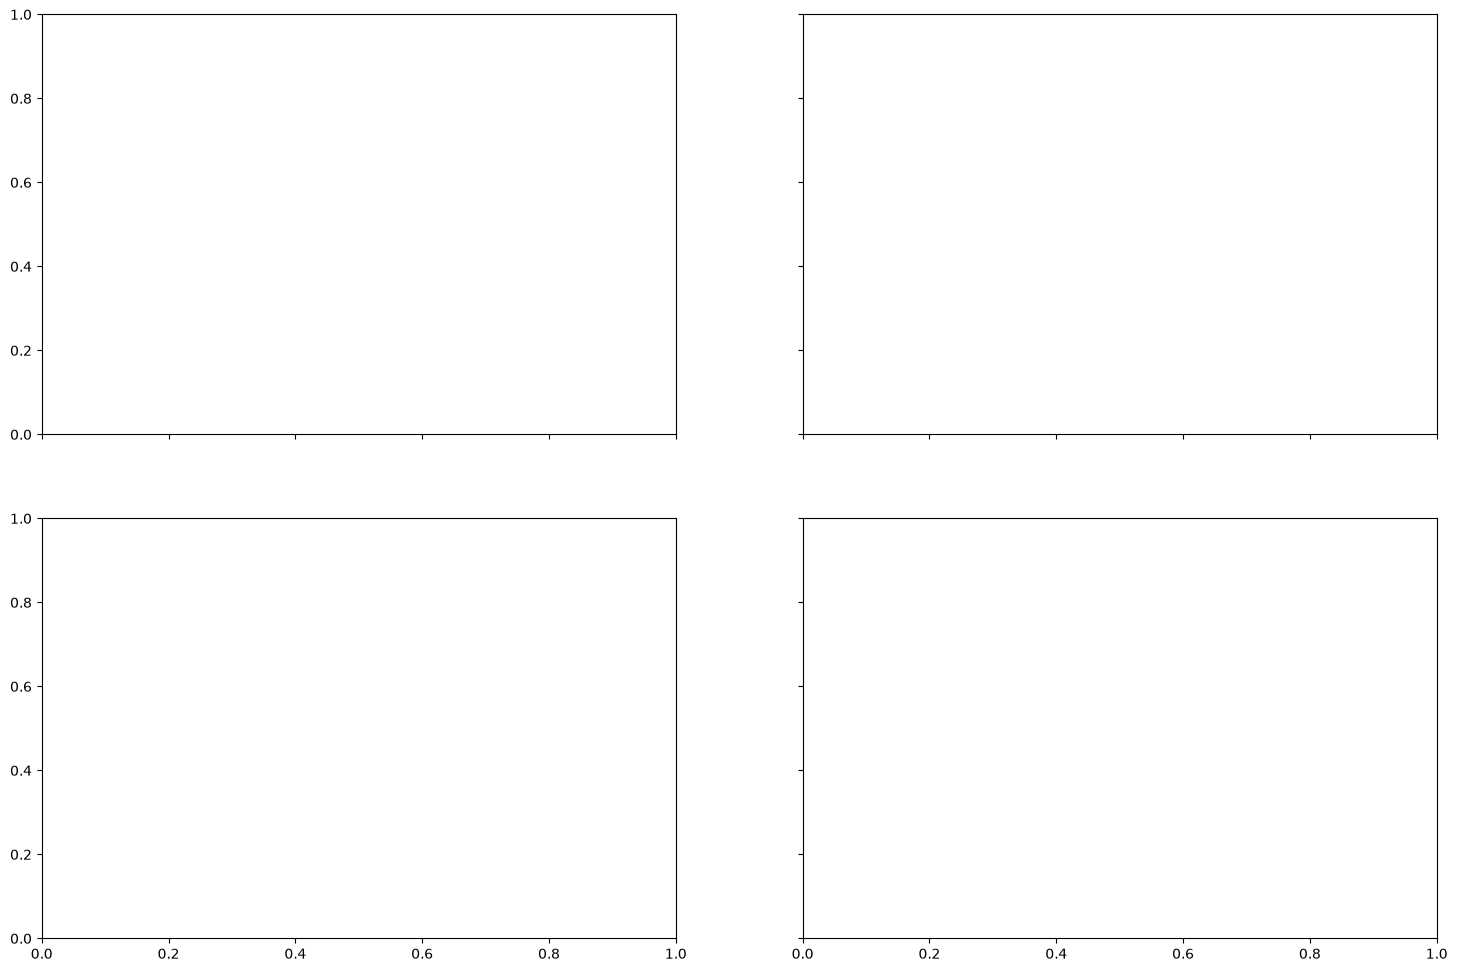

<class 'NameError'>: name 'iteration_df' is not defined

In [17]:
# ============================================================
# 10. PASS RATE VISUALISATION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

groups = ["SLM", "LLM"]
modes = ["Holistic", "Incremental"]

iterations = sorted(
    iteration_df["Iteration"]
    .dropna()
    .unique()
)

for row, group in enumerate(groups):

    for col, mode in enumerate(modes):

        ax = axes[row, col]

        plot_data = iteration_df[
            (iteration_df["Model Group"] == group) &
            (iteration_df["Mode"] == mode)
        ]

        for model in sorted(
            plot_data["Model"].unique()
        ):

            model_data = plot_data[
                plot_data["Model"] == model
            ].sort_values("Iteration")

            ax.plot(
                model_data["Iteration"],
                model_data["Pass Rate"],
                marker="o",
                linewidth=2,
                markersize=5,
                label=model
            )

        ax.set_title(
            f"{group}s — {mode}",
            fontsize=20,
            pad=15
        )

        ax.set_xlabel(
            "Iteration",
            fontsize=18
        )

        ax.set_ylabel(
            "Pass Rate (%)",
            fontsize=18
        )

        ax.set_xticks(
            iterations
        )

        ax.tick_params(
            axis="both",
            labelsize=15
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        ax.legend(
            fontsize=10,
            title="Model",
            title_fontsize=12
        )


fig.suptitle(
    "Pass Rate Across Iterations by Model Group and Mode",
    fontsize=24,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "pass_rate_iterations_slm_llm.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()